---
title: "Evaluating Region-Focused Preprocessing at Different Anatomical Scales"
format:
    html: 
        code-fold: false
---

## Imports

In [27]:
import os
import cv2
import glob
import yaml
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

## Setup

In [2]:
# Set base paths
base = "../data/processed/stage3_disease"
roi_base = "../data/processed/stage3_disease_roi"
quad_base = "../data/processed/stage3_disease_quadrant"

# Set class names
class_names = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical_Lesion",
    3: "Deep_Caries"
}

## Check Original Stage 3 Dataset

In [3]:
# Check original Stage 3 dataset counts
for split in ["train", "val", "test"]:
    img_dir = os.path.join(base, "images", split)
    lbl_dir = os.path.join(base, "labels", split)
    print(split)
    print("images:", len(os.listdir(img_dir)))
    print("labels:", len(os.listdir(lbl_dir)))
    print("-" * 30)

train
images: 705
labels: 705
------------------------------
val
images: 50
labels: 50
------------------------------
test
images: 250
labels: 250
------------------------------


## Define ROI and Quadrant Function

In [4]:
# Get dental ROI crop bounds
def get_roi_bounds(img):
    h, w = img.shape[:2]
    x1 = int(0.18 * w)
    x2 = int(0.82 * w)
    y1 = int(0.25 * h)
    y2 = int(0.85 * h)
    return x1, y1, x2, y2

# Get quadrant crop bounds inside the ROI
def get_quadrant_bounds(img):
    x1, y1, x2, y2 = get_roi_bounds(img)
    roi_w = x2 - x1
    roi_h = y2 - y1
    mid_x = x1 + roi_w // 2
    mid_y = y1 + roi_h // 2
    quadrants = {
        "q1": (x1, y1, mid_x, mid_y), 
        "q2": (mid_x, y1, x2, mid_y),  
        "q3": (x1, mid_y, mid_x, y2),  
        "q4": (mid_x, mid_y, x2, y2)   
    }
    return quadrants

## Define YOLO Label Transformation Function

In [5]:
# Read YOLO labels 
def read_yolo_labels(label_path):
    labels = []
    if not os.path.exists(label_path):
        return labels
    with open(label_path, "r") as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        # YOLO box label
        if len(parts) == 5:
            xc = float(parts[1])
            yc = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])
            labels.append([cls, xc, yc, bw, bh])

        # YOLO segmentation label
        else:
            coords = list(map(float, parts[1:]))
            xs = coords[0::2]
            ys = coords[1::2]
            x_min = min(xs)
            x_max = max(xs)
            y_min = min(ys)
            y_max = max(ys)
            xc = (x_min + x_max) / 2
            yc = (y_min + y_max) / 2
            bw = x_max - x_min
            bh = y_max - y_min
            labels.append([cls, xc, yc, bw, bh])
    return labels

# Convert YOLO normalized box to pixel box
def yolo_to_pixel(label, img_w, img_h):
    cls, xc, yc, bw, bh = label
    x_center = xc * img_w
    y_center = yc * img_h
    box_w = bw * img_w
    box_h = bh * img_h
    x_min = x_center - box_w / 2
    y_min = y_center - box_h / 2
    x_max = x_center + box_w / 2
    y_max = y_center + box_h / 2
    return cls, x_min, y_min, x_max, y_max

# Convert cropped pixel box back to YOLO format
def pixel_to_yolo(cls, x_min, y_min, x_max, y_max, crop_w, crop_h):
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    box_w = x_max - x_min
    box_h = y_max - y_min
    xc = x_center / crop_w
    yc = y_center / crop_h
    bw = box_w / crop_w
    bh = box_h / crop_h
    return [cls, xc, yc, bw, bh]

# Transform labels after cropping
def transform_labels_for_crop(labels, img_w, img_h, crop_box):
    crop_x1, crop_y1, crop_x2, crop_y2 = crop_box
    crop_w = crop_x2 - crop_x1
    crop_h = crop_y2 - crop_y1
    new_labels = []
    for label in labels:
        cls, x_min, y_min, x_max, y_max = yolo_to_pixel(label, img_w, img_h)
        # Use box center to decide if object belongs in this crop
        x_center = (x_min + x_max) / 2
        y_center = (y_min + y_max) / 2
        if not (crop_x1 <= x_center <= crop_x2 and crop_y1 <= y_center <= crop_y2):
            continue
        # Shift box into crop coordinates
        new_x_min = x_min - crop_x1
        new_y_min = y_min - crop_y1
        new_x_max = x_max - crop_x1
        new_y_max = y_max - crop_y1
        # Clip box to crop boundary
        new_x_min = max(0, min(new_x_min, crop_w))
        new_y_min = max(0, min(new_y_min, crop_h))
        new_x_max = max(0, min(new_x_max, crop_w))
        new_y_max = max(0, min(new_y_max, crop_h))
        # Skip invalid boxes
        if new_x_max <= new_x_min or new_y_max <= new_y_min:
            continue
        new_label = pixel_to_yolo(
            cls,
            new_x_min,
            new_y_min,
            new_x_max,
            new_y_max,
            crop_w,
            crop_h
        )
        # Keep only valid normalized boxes
        _, xc, yc, bw, bh = new_label
        if 0 <= xc <= 1 and 0 <= yc <= 1 and bw > 0 and bh > 0:
            new_labels.append(new_label)
    return new_labels

# Save YOLO labels
def save_yolo_labels(labels, out_path):
    with open(out_path, "w") as f:
        for label in labels:
            cls, xc, yc, bw, bh = label
            f.write(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

## Create ROI YOLO Dataset

In [6]:
# Create ROI dataset folders
def make_roi_dataset():
    # Process each dataset split separately
    for split in ["train", "val", "test"]:
        # Set input image and label folders
        in_img_dir = os.path.join(base, "images", split)
        in_lbl_dir = os.path.join(base, "labels", split)
        # Set output image and label folders
        out_img_dir = os.path.join(roi_base, "images", split)
        out_lbl_dir = os.path.join(roi_base, "labels", split)
        # Create output folders if they do not exist
        os.makedirs(out_img_dir, exist_ok=True)
        os.makedirs(out_lbl_dir, exist_ok=True)
        # Collect all image paths
        image_paths = sorted(glob.glob(os.path.join(in_img_dir, "*.png")))
        image_paths += sorted(glob.glob(os.path.join(in_img_dir, "*.jpg")))
        image_paths += sorted(glob.glob(os.path.join(in_img_dir, "*.jpeg")))

        # Loop through each image
        for img_path in image_paths:
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Get image file name and stem
            filename = os.path.basename(img_path)
            stem, ext = os.path.splitext(filename)
            img_h, img_w = img.shape[:2]

            # Read matching YOLO label file
            label_path = os.path.join(in_lbl_dir, stem + ".txt")
            labels = read_yolo_labels(label_path)
            crop_box = get_roi_bounds(img)
            x1, y1, x2, y2 = crop_box
            roi_img = img[y1:y2, x1:x2]

            # Transform YOLO labels 
            new_labels = transform_labels_for_crop(
                labels,
                img_w,
                img_h,
                crop_box
            )
            
            # Set output paths
            out_img_path = os.path.join(out_img_dir, filename)
            out_lbl_path = os.path.join(out_lbl_dir, stem + ".txt")
            # Save cropped ROI image
            cv2.imwrite(out_img_path, roi_img)
            save_yolo_labels(new_labels, out_lbl_path)
    print("ROI dataset created.")

# Create ROI dataset
make_roi_dataset()

ROI dataset created.


## Create Quadrant YOLO Dataset

In [7]:
# Create quadrant dataset 
def make_quadrant_dataset():
    # Process each dataset split separately
    for split in ["train", "val", "test"]:
        # Set input image and label folders
        in_img_dir = os.path.join(base, "images", split)
        in_lbl_dir = os.path.join(base, "labels", split)
        # Set output image and label folders
        out_img_dir = os.path.join(quad_base, "images", split)
        out_lbl_dir = os.path.join(quad_base, "labels", split)
        # Create output folders if they do not exist
        os.makedirs(out_img_dir, exist_ok=True)
        os.makedirs(out_lbl_dir, exist_ok=True)
        # Collect all image paths
        image_paths = sorted(glob.glob(os.path.join(in_img_dir, "*.png")))
        image_paths += sorted(glob.glob(os.path.join(in_img_dir, "*.jpg")))
        image_paths += sorted(glob.glob(os.path.join(in_img_dir, "*.jpeg")))

        # Loop through each image
        for img_path in image_paths:
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Get image file name and stem
            filename = os.path.basename(img_path)
            stem, ext = os.path.splitext(filename)
            img_h, img_w = img.shape[:2]

            # Read matching YOLO label file
            label_path = os.path.join(in_lbl_dir, stem + ".txt")
            labels = read_yolo_labels(label_path)
            quadrants = get_quadrant_bounds(img)

            # Create one cropped image for each quadrant
            for q_name, crop_box in quadrants.items():
                x1, y1, x2, y2 = crop_box
                quad_img = img[y1:y2, x1:x2]
                new_labels = transform_labels_for_crop(
                    labels,
                    img_w,
                    img_h,
                    crop_box
                )

                # Create new image and label names
                new_img_name = f"{stem}_{q_name}{ext}"
                new_lbl_name = f"{stem}_{q_name}.txt"
                # Set output paths
                out_img_path = os.path.join(out_img_dir, new_img_name)
                out_lbl_path = os.path.join(out_lbl_dir, new_lbl_name)
                # Save cropped quadrant image
                cv2.imwrite(out_img_path, quad_img)
                # Save transformed YOLO labels
                save_yolo_labels(new_labels, out_lbl_path)
    print("Quadrant dataset created.")

# Create Quadrant Dataset
make_quadrant_dataset()

Quadrant dataset created.


## Check New Dataset Counts

In [8]:
# Check dataset counts
for dataset_name, dataset_path in {
    "Full": base,
    "ROI": roi_base,
    "Quadrant": quad_base
}.items():
    print(dataset_name)
    for split in ["train", "val", "test"]:
        img_dir = os.path.join(dataset_path, "images", split)
        lbl_dir = os.path.join(dataset_path, "labels", split)
        print(split)
        print("images:", len(os.listdir(img_dir)))
        print("labels:", len(os.listdir(lbl_dir)))
    print("-" * 40)

Full
train
images: 705
labels: 705
val
images: 50
labels: 50
test
images: 250
labels: 250
----------------------------------------
ROI
train
images: 705
labels: 705
val
images: 50
labels: 50
test
images: 250
labels: 250
----------------------------------------
Quadrant
train
images: 2820
labels: 2820
val
images: 200
labels: 200
test
images: 1000
labels: 1000
----------------------------------------


In [9]:
# Count empty label files
def count_empty_labels(label_dir):
    empty_count = 0

    for lbl_path in glob.glob(os.path.join(label_dir, "*.txt")):
        if os.path.getsize(lbl_path) == 0:
            empty_count += 1

    return empty_count

In [10]:
# Check empty labels
for dataset_name, dataset_path in {
    "ROI": roi_base,
    "Quadrant": quad_base
}.items():
    print(dataset_name)

    for split in ["train", "val", "test"]:
        lbl_dir = os.path.join(dataset_path, "labels", split)
        print(split, "empty labels:", count_empty_labels(lbl_dir))

    print("-" * 40)

ROI
train empty labels: 27
val empty labels: 4
test empty labels: 3
----------------------------------------
Quadrant
train empty labels: 919
val empty labels: 87
test empty labels: 265
----------------------------------------


## Visual Check of Cropped Images

In [12]:
# Draw YOLO boxes on image
def draw_yolo_boxes(img, label_path):
    out = img.copy()
    h, w = out.shape[:2]
    labels = read_yolo_labels(label_path)
    for label in labels:
        cls, xc, yc, bw, bh = label
        x_center = xc * w
        y_center = yc * h
        box_w = bw * w
        box_h = bh * h
        x1 = int(x_center - box_w / 2)
        y1 = int(y_center - box_h / 2)
        x2 = int(x_center + box_w / 2)
        y2 = int(y_center + box_h / 2)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            out,
            str(cls),
            (x1, max(y1 - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )
    return out

### ROI

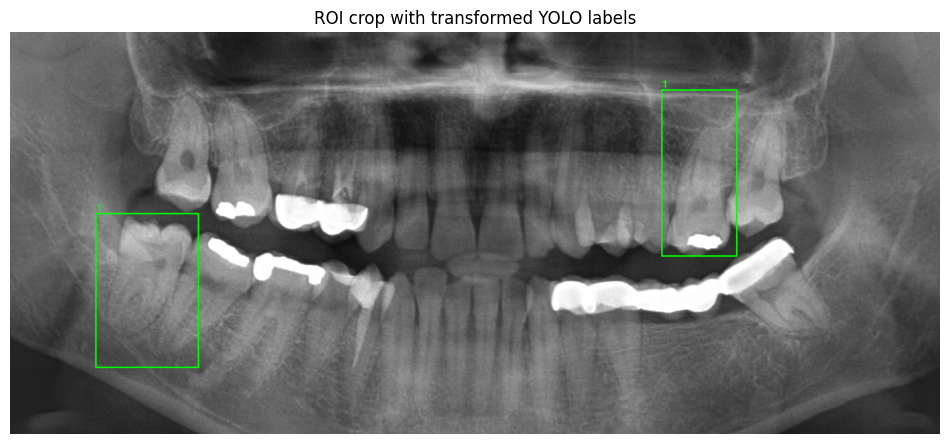

In [13]:
# Show one ROI example with boxes
roi_img_path = sorted(glob.glob(os.path.join(roi_base, "images", "train", "*")))[0]
roi_stem = os.path.splitext(os.path.basename(roi_img_path))[0]
roi_lbl_path = os.path.join(roi_base, "labels", "train", roi_stem + ".txt")
roi_img = cv2.imread(roi_img_path)
roi_boxed = draw_yolo_boxes(roi_img, roi_lbl_path)
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(roi_boxed, cv2.COLOR_BGR2RGB))
plt.title("ROI crop with transformed YOLO labels")
plt.axis("off")
plt.show()

### Quadrant

In [18]:
# Show first non-empty quadrant label file
quad_label_paths = sorted(glob.glob(os.path.join(quad_base, "labels", "train", "*.txt")))
for lbl_path in quad_label_paths:
    if os.path.getsize(lbl_path) > 0:
        print("Found non-empty label:", lbl_path)
        print(open(lbl_path).read())
        break

Found non-empty label: ../data/processed/stage3_disease_quadrant\labels\train\train_0_q2.txt
1 0.481908 0.647208 0.161184 0.705583



Image: ../data/processed/stage3_disease_quadrant\images\train\train_0_q2.png
Label: ../data/processed/stage3_disease_quadrant\labels\train\train_0_q2.txt


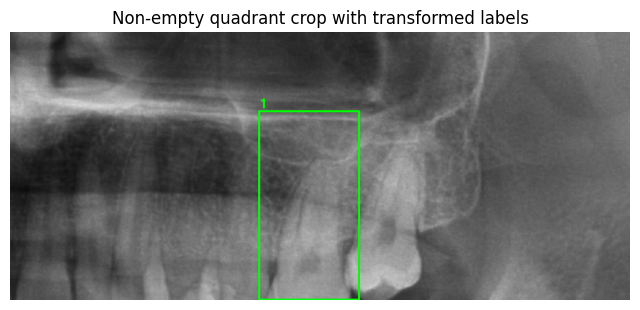

In [ ]:
# Visualize first non-empty quadrant crop
for lbl_path in quad_label_paths:
    if os.path.getsize(lbl_path) > 0:
        stem = os.path.splitext(os.path.basename(lbl_path))[0]
        img_path = os.path.join(quad_base, "images", "train", stem + ".jpg")
        if not os.path.exists(img_path):
            img_path = os.path.join(quad_base, "images", "train", stem + ".png")
        if not os.path.exists(img_path):
            img_path = os.path.join(quad_base, "images", "train", stem + ".jpeg")
        img = cv2.imread(img_path)
        boxed = draw_yolo_boxes(img, lbl_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
        plt.title("Non-empty quadrant crop with transformed labels")
        plt.axis("off")
        plt.show()
        break

## Create YOLO YAML Files

In [21]:
# Save YOLO yaml
def save_yaml(data, filename):
    with open(filename, "w") as f:
        yaml.dump(data, f, sort_keys=False)
    print(filename)
    print(open(filename).read())

# Full image YAML
full_yaml = {
    "path": base,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 4,
    "names": class_names
}
save_yaml(full_yaml, "rq4_stage3_full.yaml")

# ROI YAML
roi_yaml = {
    "path": roi_base,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 4,
    "names": class_names
}
save_yaml(roi_yaml, "rq4_stage3_roi.yaml")

# Quadrant YAML
quad_yaml = {
    "path": quad_base,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 4,
    "names": class_names
}
save_yaml(quad_yaml, "rq4_stage3_quadrant.yaml")

rq4_stage3_full.yaml
path: ../data/processed/stage3_disease
train: images/train
val: images/val
test: images/test
nc: 4
names:
  0: Impacted
  1: Caries
  2: Periapical_Lesion
  3: Deep_Caries

rq4_stage3_roi.yaml
path: ../data/processed/stage3_disease_roi
train: images/train
val: images/val
test: images/test
nc: 4
names:
  0: Impacted
  1: Caries
  2: Periapical_Lesion
  3: Deep_Caries

rq4_stage3_quadrant.yaml
path: ../data/processed/stage3_disease_quadrant
train: images/train
val: images/val
test: images/test
nc: 4
names:
  0: Impacted
  1: Caries
  2: Periapical_Lesion
  3: Deep_Caries



## Train Full-Image YOLOv8 Model

In [25]:
# Train full-image YOLOv8 model
full_train_model = YOLO("yolov8n.pt")
full_train_results = full_train_model.train(
    data="rq4_stage3_full.yaml",
    epochs=50,
    patience=10,
    imgsz=640,
    batch=16,
    name="rq4_full_yolo"
)

# Load best full-image model
full_best = YOLO("runs/detect/rq4_full_yolo/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rq4_stage3_full.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

## Train ROI Model

In [28]:
# Train ROI YOLOv8 model
roi_train_model = YOLO("yolov8n.pt")
roi_train_results = roi_train_model.train(
    data="rq4_stage3_roi.yaml",
    epochs=50,
    patience=10,
    imgsz=640,
    batch=16,
    name="rq4_roi_yolo"
)

# Load best ROI model automatically
roi_save_dir = Path(roi_train_model.trainer.save_dir)
roi_best = YOLO(str(roi_save_dir / "weights" / "best.pt"))
print("Loaded ROI model from:", roi_save_dir / "weights" / "best.pt")

New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rq4_stage3_roi.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

## Train Quadrant Model

In [29]:
# Train quadrant YOLOv8 model
quad_train_model = YOLO("yolov8n.pt")
quad_train_results = quad_train_model.train(
    data="rq4_stage3_quadrant.yaml",
    epochs=50,
    patience=10,
    imgsz=640,
    batch=16,
    name="rq4_quadrant_yolo"
)

New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rq4_stage3_quadrant.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0,

In [30]:
# Load best quadrant model automatically
quad_save_dir = Path(quad_train_model.trainer.save_dir)
quad_best = YOLO(str(quad_save_dir / "weights" / "best.pt"))
print("Loaded quadrant model from:", quad_save_dir / "weights" / "best.pt")

Loaded quadrant model from: C:\GitHub Local\6600-dental-enumeration-and-condition\methods\runs\detect\rq4_quadrant_yolo\weights\best.pt


## Evaluate Models

### Original

In [31]:
# Evaluate full-image model
full_metrics = full_best.val(
    data="rq4_stage3_full.yaml",
    split="test"
)

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1561.0386.9 MB/s, size: 4175.9 KB)
val: Scanning C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease\labels\test.cache... 250 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 9.4it/s 1.7s<0.1s
                   all        250       1469      0.378      0.431       0.36      0.232
              Impacted         91        221      0.857       0.91      0.938      0.588
                Caries        226        747      0.285      0.764      0.359      0.256
     Periapical_Lesion        112        236      0.351     0.0297      0.126      0.074
           Deep_Caries         81        265     0.0205     0.01

### ROI model

In [32]:
# Evaluate ROI model
roi_metrics = roi_best.val(
    data="rq4_stage3_roi.yaml",
    split="test"
)

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 293.743.8 MB/s, size: 1566.7 KB)
val: Scanning C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease_roi\labels\test... 250 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 318.9it/s 0.8s0.1s
val: New cache created: C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease_roi\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 11.0it/s 1.5s0.1s
                   all        250       1460      0.394      0.467      0.405      0.268
              Impacted         90        216      0.816      0.945      0.949      0.609
                Caries        226        746      0.303      0.753      0.413      0.303
     Periapica

### Quadrant model

In [33]:
# Evaluate quadrant model
quad_metrics = quad_best.val(
    data="rq4_stage3_quadrant.yaml",
    split="test"
)

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 92.814.8 MB/s, size: 468.9 KB)
val: Scanning C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease_quadrant\labels\test... 1000 images, 265 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 803.7it/s 1.2s0s
val: New cache created: C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease_quadrant\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 20.3it/s 3.1s0.1s
                   all       1000       1460      0.429      0.426      0.402      0.274
              Impacted        213        216      0.813      0.906      0.912      0.614
                Caries        489        746      0.383      0.645      0.443      0.319
   

## Build Results Table

In [34]:
# Build RQ4 comparison table
rq4_table = pd.DataFrame({
    "Model": ["Full image", "Dental ROI", "Quadrants"],
    "mAP50": [
        full_metrics.box.map50,
        roi_metrics.box.map50,
        quad_metrics.box.map50
    ],
    "mAP50-95": [
        full_metrics.box.map,
        roi_metrics.box.map,
        quad_metrics.box.map
    ]
})
rq4_table

,Model,mAP50,mAP50-95
0,Full image,0.359875,0.232347
1,Dental ROI,0.405427,0.267625
2,Quadrants,0.401869,0.274097


In [35]:
# Add difference from full-image baseline
full_map50 = rq4_table.loc[rq4_table["Model"] == "Full image", "mAP50"].values[0]
full_map = rq4_table.loc[rq4_table["Model"] == "Full image", "mAP50-95"].values[0]
rq4_table["mAP50_Difference_From_Full"] = rq4_table["mAP50"] - full_map50
rq4_table["mAP50-95_Difference_From_Full"] = rq4_table["mAP50-95"] - full_map

rq4_table

,Model,mAP50,mAP50-95,mAP50_Difference_From_Full,mAP50-95_Difference_From_Full
0,Full image,0.359875,0.232347,0.000000,0.000000
1,Dental ROI,0.405427,0.267625,0.045553,0.035277
2,Quadrants,0.401869,0.274097,0.041995,0.041749


In [39]:
best_row = rq4_table.sort_values("mAP50", ascending=False).iloc[0]
print("Best RQ4 setting:", best_row["Model"])
print("Best mAP50:", best_row["mAP50"])

Best RQ4 setting: Dental ROI
Best mAP50: 0.40542736220333553


## Plot Results

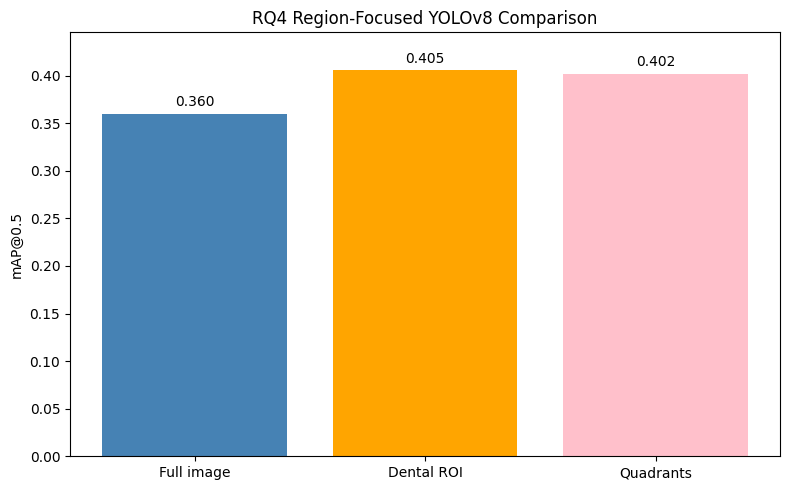

In [48]:
plt.figure(figsize=(8, 5))
colors = ["steelblue", "orange", "pink"]
bars = plt.bar(
    rq4_table["Model"],
    rq4_table["mAP50"],
    color=colors
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.ylabel("mAP@0.5")
plt.title("RQ4 Region-Focused YOLOv8 Comparison")
plt.ylim(0, max(rq4_table["mAP50"]) + 0.04)
plt.tight_layout()
plt.show()